In [3]:
import sys
print(sys.executable)

/scratch/users/hao_huang/conda/envs/215a/bin/python


In [4]:
import pandas as pd

1.1 Loading the data

In [5]:
coord = pd.read_csv('../data/stateCoord.csv')
coord.head()

,State,lon,lat
0,Alabama,-86.592392,34.735676
1,Alaska,-168.187471,53.330810
2,Arizona,-111.615136,36.246377
3,Arkansas,-92.240455,36.374502
4,California,-120.386476,34.034180


In [6]:
arr = pd.read_csv('../data/USArrests.csv')
arr.head()

,State,Murder,Assault,UrbanPop,Rape
0,Alabama,13.2,236,58,21.2
1,Alaska,10.0,263,48,44.5
2,Arizona,8.1,294,80,31.0
3,Arkansas,8.8,190,50,19.5
4,California,9.0,276,91,40.6


1.2 Manipulating the data

In [7]:
print(arr.columns)
print(coord.columns)

Index(['State', 'Murder', 'Assault', 'UrbanPop', 'Rape'], dtype='str')
Index(['State         ', 'lon              ', 'lat'], dtype='str')


In [8]:
coord.columns = coord.columns.str.strip()
print(coord.columns)

Index(['State', 'lon', 'lat'], dtype='str')


In [9]:
arrests = pd.merge(arr, coord, on="State")
arrests.head()

,State,Murder,Assault,UrbanPop,Rape,lon,lat


In [10]:
print(arr["State"].head().tolist())
print(coord["State"].head().tolist())

['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California']
['Alabama       ', 'Alaska        ', 'Arizona       ', 'Arkansas      ', 'California    ']


In [11]:
coord["State"] = coord["State"].str.strip()
print(coord["State"].head().tolist())

['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California']


In [12]:
arrests = pd.merge(arr, coord, on="State")
arrests.head()

,State,Murder,Assault,UrbanPop,Rape,lon,lat
0,Alabama,13.2,236,58,21.2,-86.592392,34.735676
1,Alaska,10.0,263,48,44.5,-168.187471,53.330810
2,Arizona,8.1,294,80,31.0,-111.615136,36.246377
3,Arkansas,8.8,190,50,19.5,-92.240455,36.374502
4,California,9.0,276,91,40.6,-120.386476,34.034180


1.3 Visualizaing the data

1) murder vs assault

In [13]:
import matplotlib.pyplot as plt

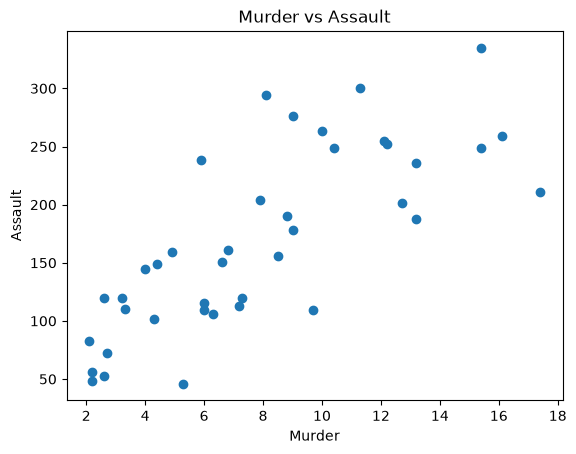

In [14]:
plt.scatter(arrests["Murder"], arrests["Assault"])
plt.xlabel("Murder")
plt.ylabel("Assault")
plt.title("Murder vs Assault")

plt.show()

States with higher murder rates also tend to have higher assault rates. Strong positive relationship

2) rape vs urban population

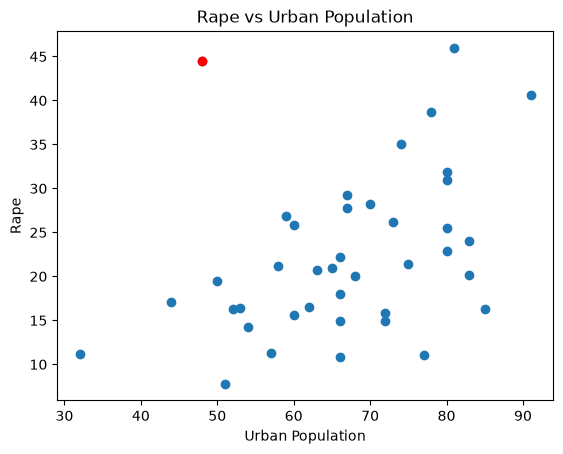

In [15]:
plt.scatter(arrests["UrbanPop"], arrests["Rape"])
plt.xlabel("Urban Population")
plt.ylabel("Rape")
plt.title("Rape vs Urban Population")

outlier = arrests[arrests["State"] == "Alaska"]
plt.scatter(outlier["UrbanPop"], outlier["Rape"], color="red")

plt.show()

3) remake

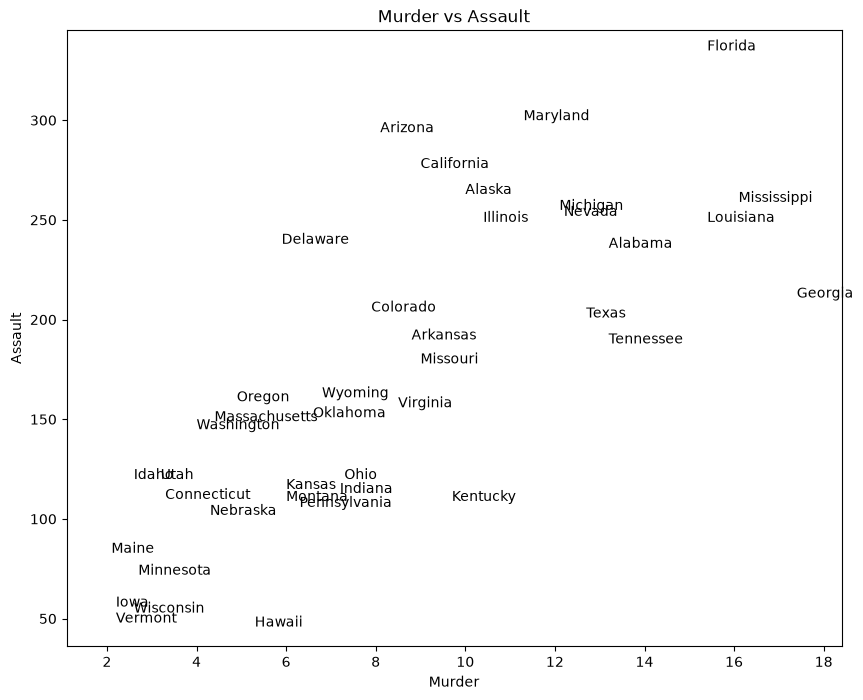

In [16]:
plt.figure(figsize=(10, 8))

for _, row in arrests.iterrows():
    plt.annotate(row["State"],(row["Murder"], row["Assault"]))

plt.xlabel("Murder")
plt.ylabel("Assault")
plt.title("Murder vs Assault")

plt.xlim(arrests["Murder"].min() - 1, arrests["Murder"].max() + 1)
plt.ylim(arrests["Assault"].min() - 10, arrests["Assault"].max() + 10)

plt.show()

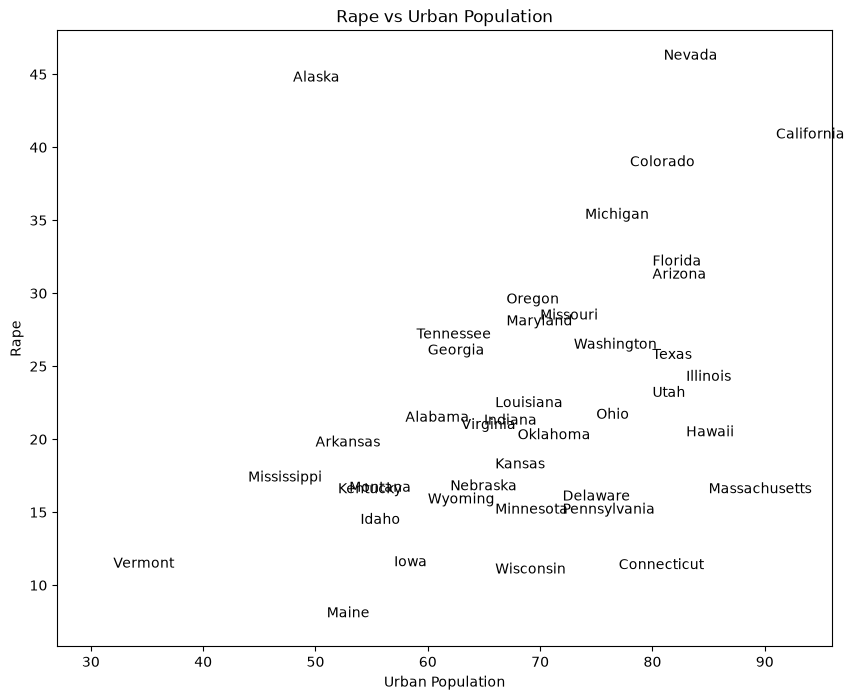

In [17]:
plt.figure(figsize=(10, 8))

for _, row in arrests.iterrows():
    plt.annotate(row["State"],(row["UrbanPop"], row["Rape"]))

plt.xlabel("Urban Population")
plt.ylabel("Rape")
plt.title("Rape vs Urban Population")

plt.xlim(arrests["UrbanPop"].min() - 5, arrests["UrbanPop"].max() + 5)
plt.ylim(arrests["Rape"].min() - 2, arrests["Rape"].max() + 2)

plt.show()

1.4 regression

1) 

In [18]:
new_arr = arrests.drop(columns=["Murder", "Assault"])
new_arr.head()

,State,UrbanPop,Rape,lon,lat
0,Alabama,58,21.2,-86.592392,34.735676
1,Alaska,48,44.5,-168.187471,53.330810
2,Arizona,80,31.0,-111.615136,36.246377
3,Arkansas,50,19.5,-92.240455,36.374502
4,California,91,40.6,-120.386476,34.034180


2)

In [19]:
from sklearn.linear_model import LinearRegression

X = new_arr[["UrbanPop"]]
y = new_arr["Rape"]

model = LinearRegression()
model.fit(X, y)

predicted = model.predict(X)
residuals = y - predicted

3)

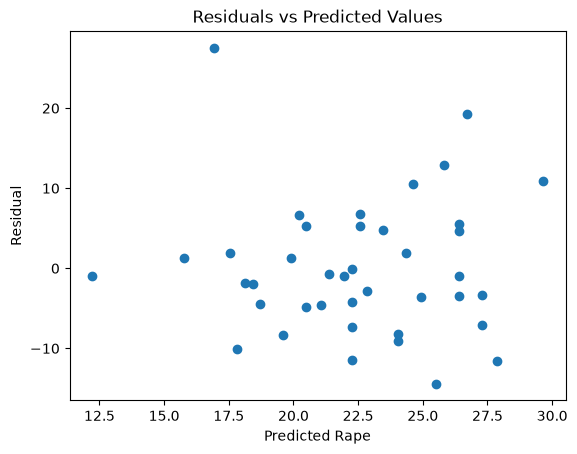

In [22]:
plt.scatter(predicted, residuals)
plt.xlabel("Predicted Rape")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted Values")

plt.show()

4)

/scratch/users/hao_huang/conda/envs/215a/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


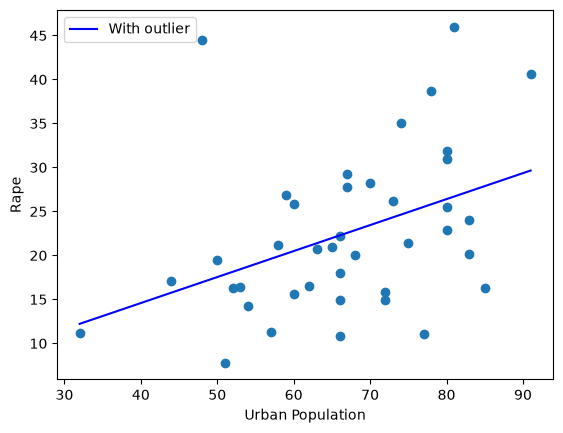

In [23]:
import numpy as np

x_line = np.linspace(
    new_arr["UrbanPop"].min(),
    new_arr["UrbanPop"].max(),
    100
).reshape(-1, 1)

y_line = model.predict(x_line)

plt.scatter(new_arr["UrbanPop"], new_arr["Rape"])

plt.plot(
    x_line,
    y_line,
    color="blue",
    label="With outlier"
)

plt.xlabel("Urban Population")
plt.ylabel("Rape")
plt.legend()

plt.show()

5)

In [29]:
clean_data = new_arr.drop(index=outlier.index)

X_clean = clean_data[["UrbanPop"]]
y_clean = clean_data["Rape"]

model_clean = LinearRegression()
model_clean.fit(X_clean, y_clean)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.38]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['UrbanPop']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-3.865
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
